In [7]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img



In [8]:
data_dir = "data"
categorias = ["tiki", "casi_tiki", "descarte"]
augmented_dir = "dataset_ropa_aumentado"

In [9]:
if not os.path.exists(augmented_dir):
    os.makedirs(augmented_dir)
    for category in categorias:
        os.makedirs(os.path.join(augmented_dir, category))

In [10]:
# Parámetros
target_size = (224, 224)
batch_size = 32
num_augmented_images = {"tiki": 15, "casi_tiki": 10, "descarte": 20}

In [11]:
augmentor = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=40,
    width_shift_range=0.3,
    height_shift_range=0.3,
    shear_range=0.3,
    
    zoom_range=0.4,
    brightness_range=[0.8,1.2],
    horizontal_flip=True,
    fill_mode='nearest'
)

for category in categorias:
    input_folder = os.path.join(data_dir, category)
    output_folder = os.path.join(augmented_dir, category)
    
    for filename in os.listdir(input_folder):
        img_path = os.path.join(input_folder, filename)
        img = load_img(img_path, target_size=target_size)
        img_array = img_to_array(img)
        img_array = img_array.reshape((1,) + img_array.shape)
        
        i = 0
        for batch in augmentor.flow(img_array, batch_size=1, save_to_dir=output_folder, save_prefix="aug", save_format="jpeg"):
            i += 1
            if i >= num_augmented_images[category]:
                break

KeyboardInterrupt: 

In [12]:
# Generadores de datos
gen_datagen = ImageDataGenerator(
    validation_split=0.2
)

train_generator = gen_datagen.flow_from_directory(
    augmented_dir,
    target_size=target_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_generator = gen_datagen.flow_from_directory(
    augmented_dir,
    target_size=target_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

Found 9682 images belonging to 3 classes.
Found 2420 images belonging to 3 classes.


In [13]:
X_val, y_val = [], []

for i in range(len(val_generator)):
    x_batch, y_batch = val_generator[i]
    X_val.extend(x_batch)
    y_val.extend(y_batch)

X_val = np.array(X_val)
y_val = np.array(y_val)

In [14]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = True 

for layer in base_model.layers[:140]:
    layer.trainable = False


In [15]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(64, activation='relu')(x)
out = Dense(len(categorias), activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=out)

In [16]:
optimizer = keras.optimizers.AdamW(learning_rate=0.00001)
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

In [17]:
epochs = 50
model.fit(train_generator, validation_data=val_generator, epochs=epochs, callbacks=[early_stopping])
model.save("modelo_ropa_cat.keras")
print("Modelo entrenado y guardado correctamente.")

Epoch 1/50


c:\Users\bulla\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


303/303 ━━━━━━━━━━━━━━━━━━━━ 265s 843ms/step - accuracy: 0.4250 - loss: 1.1246 - val_accuracy: 0.5781 - val_loss: 0.9851
Epoch 2/50
303/303 ━━━━━━━━━━━━━━━━━━━━ 266s 879ms/step - accuracy: 0.5973 - loss: 0.8864 - val_accuracy: 0.6240 - val_loss: 0.8593
Epoch 3/50
303/303 ━━━━━━━━━━━━━━━━━━━━ 271s 896ms/step - accuracy: 0.6463 - loss: 0.7871 - val_accuracy: 0.6930 - val_loss: 0.7608
Epoch 4/50
303/303 ━━━━━━━━━━━━━━━━━━━━ 266s 878ms/step - accuracy: 0.6809 - loss: 0.7124 - val_accuracy: 0.7376 - val_loss: 0.6896
Epoch 5/50
303/303 ━━━━━━━━━━━━━━━━━━━━ 271s 896ms/step - accuracy: 0.6871 - loss: 0.6981 - val_accuracy: 0.7562 - val_loss: 0.6271
Epoch 6/50
303/303 ━━━━━━━━━━━━━━━━━━━━ 279s 919ms/step - accuracy: 0.6983 - loss: 0.6602 - val_accuracy: 0.7566 - val_loss: 0.5897
Epoch 7/50
303/303 ━━━━━━━━━━━━━━━━━━━━ 262s 865ms/step - accuracy: 0.7183 - loss: 0.6124 - val_accuracy: 0.7628 - val_loss: 0.5508
Epoch 8/50
303/303 ━━━━━━━━━━━━━━━━━━━━ 259s 853ms/step - accuracy: 0.7189 - loss: 0.61

76/76 ━━━━━━━━━━━━━━━━━━━━ 51s 642ms/step


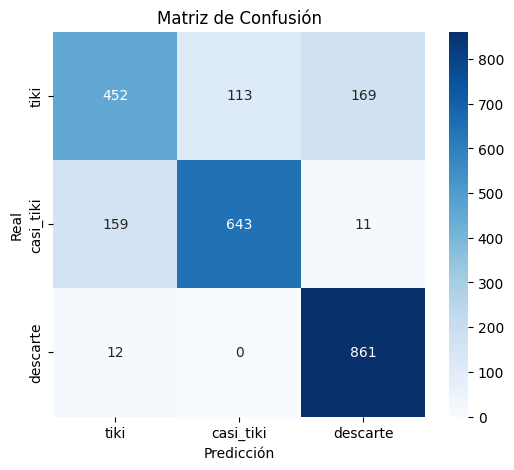

              precision    recall  f1-score   support

        tiki       0.73      0.62      0.67       734
   casi_tiki       0.85      0.79      0.82       813
    descarte       0.83      0.99      0.90       873

    accuracy                           0.81      2420
   macro avg       0.80      0.80      0.80      2420
weighted avg       0.80      0.81      0.80      2420



In [18]:
# Evaluación con matriz de confusión
model = keras.models.load_model("modelo_ropa_cat.keras")

y_pred = np.argmax(model.predict(X_val), axis=1)
y_true = np.argmax(y_val, axis=1)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=categorias, yticklabels=categorias)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()

print(classification_report(y_true, y_pred, target_names=categorias))